In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import csv
import requests
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from joblib import dump, load

In [2]:
#load weather data
df = pd.read_csv("https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&stations=USW00094728&startDate=2000-09-01&endDate=2026-01-01&dataTypes=TMAX,TMIN&format=csv&units=standard")

In [3]:
#preprocess datetime format
df_filtered = df[["DATE", "TMAX", "TMIN"]]
df_filtered = df_filtered.rename(columns={"DATE": "Date"})
df_filtered["Date"] = pd.to_datetime(df_filtered["Date"])

In [4]:
#load oil data
oil = yf.Ticker("HO=F")
value = oil.history(start='2000-09-01', end='2026-01-01').reset_index()

In [5]:
#remove local timezones
value["Date"] = pd.to_datetime(value["Date"]).dt.tz_localize(None).dt.normalize()

In [6]:
#merge data
merged =pd.merge(value, df_filtered, on="Date", how="left")

In [7]:
#split training and test data
X1 = merged[["TMAX", "TMIN"]]
y1 = merged["Close"]

split = int(len(merged) * 0.8)
X1_train, X1_test = X1.iloc[:split], X1.iloc[split:]
y1_train, y1_test = y1.iloc[:split], y1.iloc[split:]

In [8]:
X1.isna().sum()

TMAX    0
TMIN    0
dtype: int64

In [9]:
#linera regression model
lr = LinearRegression()
lr.fit(X1_train, y1_train)
pred_lr1 = lr.predict(X1_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y1_test, pred_lr1))
print("RMSE:", mean_squared_error(y1_test, pred_lr1)**0.5)
print("R2:", r2_score(y1_test, pred_lr1))

Linear Regression
MAE: 0.7822164287918422
RMSE: 0.979229147960995
R2: -1.5399374357417037


In [10]:
#random forest model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)
rf.fit(X1_train, y1_train)
pred_rf1 = rf.predict(X1_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y1_test, pred_rf1))
print("RMSE:", mean_squared_error(y1_test, pred_rf1)**0.5)
print("R2:", r2_score(y1_test, pred_rf1))

Random Forest
MAE: 0.7866931222620329
RMSE: 0.9849567758594414
R2: -1.569737125637098


In [11]:
#xgboost model
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X1_train, y1_train)
pred_gbr1 = gbr.predict(X1_test)

print("Gradient Boosting")
print("MAE:", mean_absolute_error(y1_test, pred_gbr1))
print("RMSE:", mean_squared_error(y1_test, pred_gbr1)**0.5)
print("R2:", r2_score(y1_test, pred_gbr1))

Gradient Boosting
MAE: 0.7878954862181984
RMSE: 0.986694002237387
R2: -1.5788099136585645


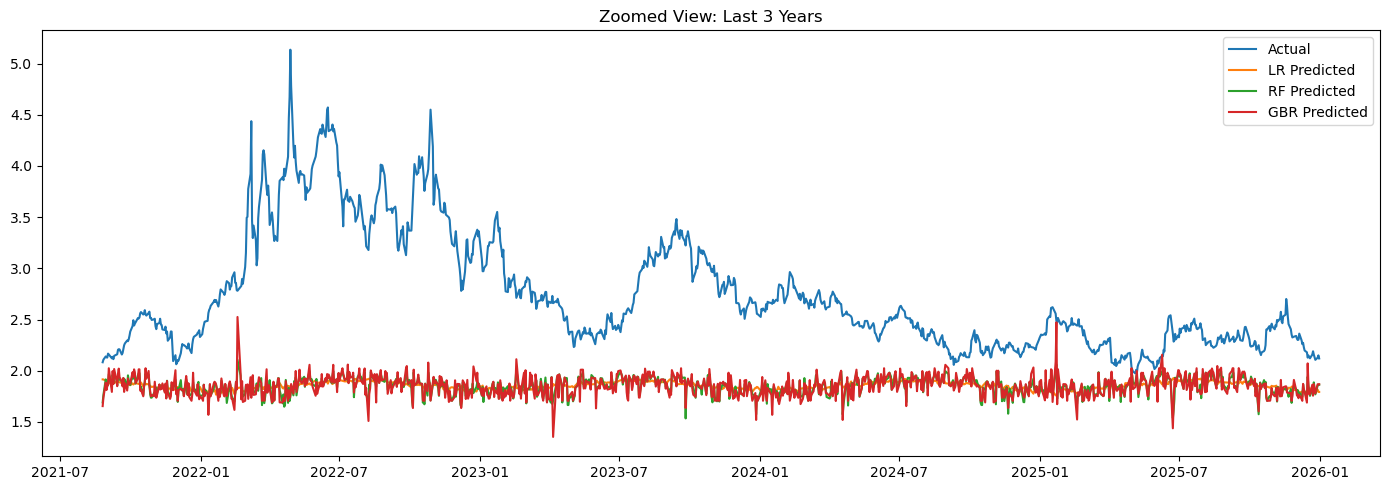

In [12]:
#visualise results
dates = merged.loc[y1_test.index, "Date"]

window = 365 * 3  # last 3 years

plt.figure(figsize=(14, 5))
plt.plot(dates[-window:], y1_test.values[-window:], label="Actual")
plt.plot(dates[-window:], pred_lr1[-window:], label="LR Predicted")
plt.plot(dates[-window:], pred_rf1[-window:], label="RF Predicted")
plt.plot(dates[-window:], pred_gbr1[-window:], label="GBR Predicted")

plt.title("Zoomed View: Last 3 Years")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
#noticed the model could not accurately follow global changes
#adding crude oil as a feature
crude_oil = yf.Ticker("CL=F")
crude_value = crude_oil.history(start='2000-09-01', end='2026-01-01').reset_index()
crude_value["Date"] = pd.to_datetime(crude_value["Date"]).dt.tz_localize(None).dt.normalize()

crude_value = crude_value[["Date", "Close"]].rename(columns={"Close": "Crude_Close"})

feature_merge = pd.merge(merged, crude_value, on="Date", how="left")

print(feature_merge[["Date", "Close", "Crude_Close"]].head())
print(feature_merge["Crude_Close"].isna().sum())
print(feature_merge[feature_merge["Crude_Close"].isna()])

        Date   Close  Crude_Close
0 2000-09-01  0.9764    33.380001
1 2000-09-05  0.9797    33.799999
2 2000-09-06  0.9966    34.950001
3 2000-09-07  1.0295    35.330002
4 2000-09-08  0.9949    33.700001
2
           Date    Open    High     Low   Close  Volume  Dividends  \
1055 2004-11-25  1.4516  1.4516  1.4516  1.4516   20962        0.0   
5831 2023-11-23  2.8781  2.8948  2.8450  2.8712   33069        0.0   

      Stock Splits  TMAX  TMIN  Crude_Close  
1055           0.0    65    35          NaN  
5831           0.0    52    44          NaN  


In [14]:
#prepare model
data = feature_merge.copy()

# Temperature features
data["TAVG"] = (data["TMAX"] + data["TMIN"]) / 2
data["TAVG_lag7"] = data["TAVG"].shift(7)
data["TAVG_roll14"] = data["TAVG"].rolling(14).mean()

# Crude oil lags
data["Crude_lag1"] = data["Crude_Close"].shift(1)
data["Crude_lag5"] = data["Crude_Close"].shift(5)

# Close price lags
data["Close_lag1"] = data["Close"].shift(1)
data["Close_lag5"] = data["Close"].shift(5)
data["Close_roll7"] = data["Close"].rolling(7).mean()

df_model = data.dropna().reset_index(drop=True)

In [15]:
#define variables
X2 = df_model[
    [
        "TMAX",
        "TMIN",
        "TAVG",
        "TAVG_lag7",
        "TAVG_roll14",
        "Crude_Close",
        "Crude_lag1",
        "Crude_lag5",
        "Close_lag1",
        "Close_lag5",
        "Close_roll7"
    ]
]

y2 = df_model["Close"]

In [16]:
#split dataset
split = int(len(df_model) * 0.8)

X2_train, X2_test = X2.iloc[:split], X2.iloc[split:]
y2_train, y2_test = y2.iloc[:split], y2.iloc[split:]

In [17]:
lr = LinearRegression()
lr.fit(X2_train, y2_train)

pred_lr2 = lr.predict(X2_test)

print("Linear Regrssion")
print("MAE:", mean_absolute_error(y2_test, pred_lr2))
print("Linear RMSE:", mean_squared_error(y2_test, pred_lr2)**0.5)
print("Linear R2:", r2_score(y2_test, pred_lr2))

Linear Regrssion
MAE: 0.03731824276118019
Linear RMSE: 0.0629927018602392
Linear R2: 0.9894882042697547


In [18]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=6,
    random_state=42
)

rf.fit(X2_train, y2_train)
pred_rf2 = rf.predict(X2_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y2_test, pred_rf2))
print("RF RMSE:", mean_squared_error(y2_test, pred_rf2)**0.5)
print("RF R2:", r2_score(y2_test, pred_rf2))

Random Forest
MAE: 0.10455712015536879
RF RMSE: 0.22850680107347518
RF R2: 0.8616769038773616


In [19]:
gbr = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X2_train, y2_train)
pred_gbr2 = gbr.predict(X2_test)

print("Gradient Boosting")
print("MAE:", mean_absolute_error(y2_test, pred_gbr2))
print("GBR RMSE:", mean_squared_error(y2_test, pred_gbr2)**0.5)
print("GBR R2:", r2_score(y2_test, pred_gbr2))

Gradient Boosting
MAE: 0.10218969794297302
GBR RMSE: 0.21364384060153085
GBR R2: 0.8790858316160229


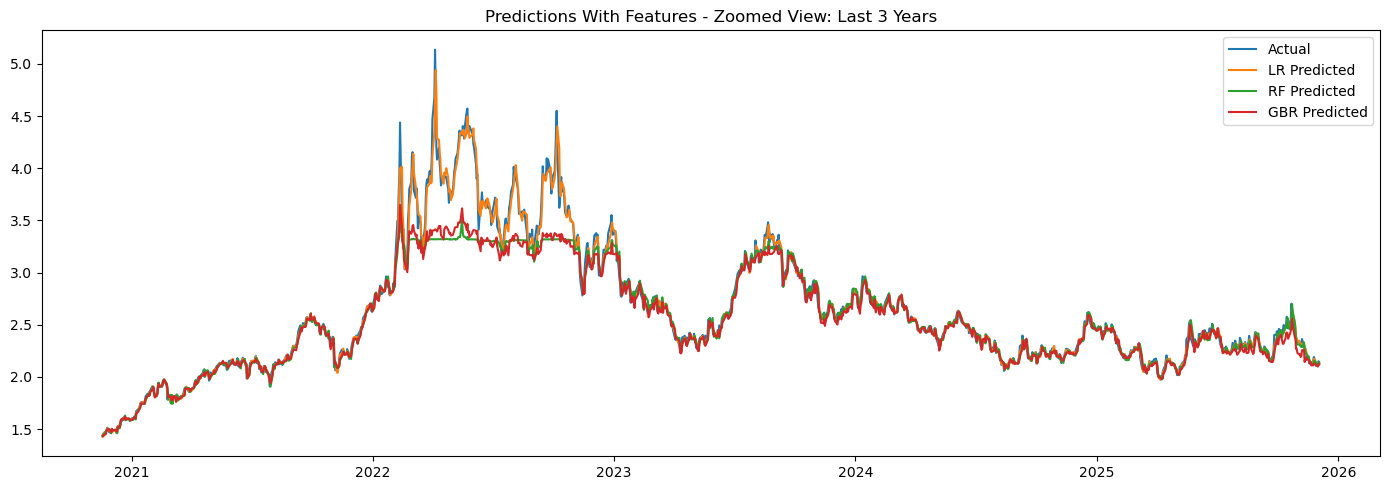

In [20]:
dates = merged.loc[y2_test.index, "Date"]

window = 365 * 4  # last 3 years

plt.figure(figsize=(14, 5))
plt.plot(dates[-window:], y2_test.values[-window:], label="Actual")
plt.plot(dates[-window:], pred_lr2[-window:], label="LR Predicted")
plt.plot(dates[-window:], pred_rf2[-window:], label="RF Predicted")
plt.plot(dates[-window:], pred_gbr2[-window:], label="GBR Predicted")

plt.title("Predictions With Features - Zoomed View: Last 3 Years")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        max_depth=6,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

perm_results = {}

for name, model in models.items():
    # Fit
    model.fit(X2_train, y2_train)

    # Permutation importance on test set
    result = permutation_importance(
        model,
        X2_test,
        y2_test,
        n_repeats=20,
        random_state=42,
        scoring="neg_root_mean_squared_error"
    )

    importances = pd.Series(
        result.importances_mean,
        index=X2_test.columns
    ).sort_values(ascending=False)

    perm_results[name] = importances

    print(f"\n{name} – Permutation Importance (RMSE impact)")
    print(importances)


Linear – Permutation Importance (RMSE impact)
TAVG           3.305345e+11
TMAX           1.753655e+11
TMIN           1.589300e+11
Close_roll7    4.657765e-01
Close_lag1     4.588931e-01
Crude_Close    1.910607e-01
Close_lag5     1.377659e-01
Crude_lag1     1.281564e-01
Crude_lag5     2.074296e-02
TAVG_lag7      3.427355e-05
TAVG_roll14    1.113924e-05
dtype: float64

RandomForest – Permutation Importance (RMSE impact)
Close_lag1     0.506729
Close_roll7    0.031132
Crude_Close    0.002231
Close_lag5     0.000213
Crude_lag1     0.000154
Crude_lag5     0.000072
TAVG_lag7      0.000007
TAVG          -0.000015
TMAX          -0.000023
TMIN          -0.000042
TAVG_roll14   -0.000048
dtype: float64

GradientBoosting – Permutation Importance (RMSE impact)
Close_lag1     0.455465
Crude_Close    0.099525
Close_roll7    0.053446
Crude_lag5     0.001708
TAVG_roll14    0.000288
TMIN           0.000172
TAVG_lag7      0.000119
TAVG          -0.000108
Close_lag5    -0.000157
TMAX          -0.000182
C

In [22]:
predict_change = data.copy()
print(predict_change.head())

        Date   Open   High     Low   Close  Volume  Dividends  Stock Splits  \
0 2000-09-01  0.985  0.991  0.9705  0.9764   14679        0.0           0.0   
1 2000-09-05  0.995  0.998  0.9750  0.9797   17365        0.0           0.0   
2 2000-09-06  0.985  1.000  0.9810  0.9966   18879        0.0           0.0   
3 2000-09-07  0.990  1.030  0.9880  1.0295   23851        0.0           0.0   
4 2000-09-08  1.012  1.020  0.9910  0.9949   23189        0.0           0.0   

   TMAX  TMIN  Crude_Close  TAVG  TAVG_lag7  TAVG_roll14  Crude_lag1  \
0    83    74    33.380001  78.5        NaN          NaN         NaN   
1    67    52    33.799999  59.5        NaN          NaN   33.380001   
2    68    54    34.950001  61.0        NaN          NaN   33.799999   
3    71    54    35.330002  62.5        NaN          NaN   34.950001   
4    76    58    33.700001  67.0        NaN          NaN   35.330002   

   Crude_lag5  Close_lag1  Close_lag5  Close_roll7  
0         NaN         NaN         NaN  

In [23]:
print(predict_change.isna().sum())

Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
Dividends        0
Stock Splits     0
TMAX             0
TMIN             0
Crude_Close      2
TAVG             0
TAVG_lag7        7
TAVG_roll14     13
Crude_lag1       3
Crude_lag5       7
Close_lag1       1
Close_lag5       5
Close_roll7      6
dtype: int64


In [24]:
predict_change["Change"] = predict_change["Close"].pct_change().shift(-1)
predict_change["Change_lag1"] = predict_change["Close"].pct_change()
predict_change["Change_lag5"] = predict_change["Close"].pct_change(5)

In [25]:
predict_change.loc[predict_change.isnull().any(axis=1)]

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,TMAX,TMIN,...,TAVG_lag7,TAVG_roll14,Crude_lag1,Crude_lag5,Close_lag1,Close_lag5,Close_roll7,Change,Change_lag1,Change_lag5
0,2000-09-01,0.9850,0.9910,0.9705,0.9764,14679,0.0,0.0,83,74,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003380,NaN,NaN
1,2000-09-05,0.9950,0.9980,0.9750,0.9797,17365,0.0,0.0,67,52,...,NaN,NaN,33.380001,NaN,0.9764,NaN,NaN,0.017250,0.003380,NaN
2,2000-09-06,0.9850,1.0000,0.9810,0.9966,18879,0.0,0.0,68,54,...,NaN,NaN,33.799999,NaN,0.9797,NaN,NaN,0.033012,0.017250,NaN
3,2000-09-07,0.9900,1.0300,0.9880,1.0295,23851,0.0,0.0,71,54,...,NaN,NaN,34.950001,NaN,0.9966,NaN,NaN,-0.033609,0.033012,NaN
4,2000-09-08,1.0120,1.0200,0.9910,0.9949,23189,0.0,0.0,76,58,...,NaN,NaN,35.330002,NaN,1.0295,NaN,NaN,0.055181,-0.033609,NaN
5,2000-09-11,1.0050,1.0690,1.0050,1.0498,19453,0.0,0.0,77,67,...,NaN,NaN,33.700001,33.380001,0.9949,0.9764,NaN,-0.001715,0.055181,0.075174
6,2000-09-12,1.0650,1.0760,1.0320,1.0480,20280,0.0,0.0,81,70,...,NaN,NaN,35.099998,33.799999,1.0498,0.9797,1.010700,-0.035592,-0.001715,0.069715
7,2000-09-13,1.0400,1.0420,1.0000,1.0107,21068,0.0,0.0,79,66,...,78.5,NaN,34.200001,34.950001,1.0480,0.9966,1.015600,-0.003265,-0.035592,0.014148
8,2000-09-14,0.9975,1.0150,0.9805,1.0074,19287,0.0,0.0,77,60,...,59.5,NaN,33.799999,35.330002,1.0107,1.0295,1.019557,0.023427,-0.003265,-0.021467
9,2000-09-15,1.0175,1.0480,1.0170,1.0310,17450,0.0,0.0,72,59,...,61.0,NaN,34.099998,33.700001,1.0074,0.9949,1.024471,0.010669,0.023427,0.036285


In [26]:
predict_change = predict_change.dropna().reset_index(drop=True)

In [27]:
predict_change

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,TMAX,TMIN,...,TAVG_lag7,TAVG_roll14,Crude_lag1,Crude_lag5,Close_lag1,Close_lag5,Close_roll7,Change,Change_lag1,Change_lag5
0,2000-09-21,1.0100,1.0200,0.9940,1.0000,19404,0.0,0.0,74,61,...,75.5,68.357143,37.500000,34.099998,1.0185,1.0074,1.018514,-0.044500,-0.018164,-0.007346
1,2000-09-22,0.9980,1.0110,0.9520,0.9555,17141,0.0,0.0,68,56,...,72.5,67.178571,33.950001,35.849998,1.0000,1.0310,1.010629,-0.016222,-0.044500,-0.073230
2,2000-09-25,0.9425,0.9515,0.9290,0.9400,18532,0.0,0.0,63,51,...,68.5,67.000000,32.650002,36.880001,0.9555,1.0420,1.001000,-0.005319,-0.016222,-0.097889
3,2000-09-26,0.9510,0.9510,0.9215,0.9350,20569,0.0,0.0,54,50,...,65.5,66.357143,31.570000,36.500000,0.9400,1.0200,0.987286,0.013904,-0.005319,-0.083333
4,2000-09-27,0.9450,0.9595,0.9410,0.9480,18751,0.0,0.0,68,47,...,67.0,66.000000,31.500000,37.500000,0.9350,1.0185,0.973857,-0.036920,0.013904,-0.069219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6336,2025-12-23,2.1583,2.1958,2.1424,2.1906,21982,0.0,0.0,40,35,...,30.0,33.500000,58.009998,55.270000,2.1581,2.1286,2.151557,-0.015064,0.015060,0.029127
6337,2025-12-24,2.1914,2.1982,2.1557,2.1576,14110,0.0,0.0,46,35,...,24.0,34.071429,58.380001,55.939999,2.1906,2.1495,2.148271,-0.023452,-0.015064,0.003768
6338,2025-12-26,2.1623,2.1745,2.1040,2.1070,11418,0.0,0.0,29,20,...,28.0,33.964286,58.349998,56.150002,2.1576,2.1316,2.145186,0.009729,-0.023452,-0.011541
6339,2025-12-29,2.1180,2.1482,2.1143,2.1275,21740,0.0,0.0,49,31,...,38.5,34.678571,56.740002,56.660000,2.1070,2.1219,2.142043,0.010811,0.009729,0.002639


In [28]:
X3 = predict_change[
    [
        "Close",
        "TAVG_lag7",
        "Crude_Close",
        "Crude_lag1",
        "Close_lag1",
        "Close_roll7",
        "Change_lag1",
        "Change_lag5"
    ]
]

y3 = predict_change["Change"]

In [29]:
X3

,Close,TAVG_lag7,Crude_Close,Crude_lag1,Close_lag1,Close_roll7,Change_lag1,Change_lag5
0,1.0000,75.5,33.950001,37.500000,1.0185,1.018514,-0.018164,-0.007346
1,0.9555,72.5,32.650002,33.950001,1.0000,1.010629,-0.044500,-0.073230
2,0.9400,68.5,31.570000,32.650002,0.9555,1.001000,-0.016222,-0.097889
3,0.9350,65.5,31.500000,31.570000,0.9400,0.987286,-0.005319,-0.083333
4,0.9480,67.0,31.500000,31.500000,0.9350,0.973857,0.013904,-0.069219
...,...,...,...,...,...,...,...,...
6336,2.1906,30.0,58.380001,58.009998,2.1581,2.151557,0.015060,0.029127
6337,2.1576,24.0,58.349998,58.380001,2.1906,2.148271,-0.015064,0.003768
6338,2.1070,28.0,56.740002,58.349998,2.1576,2.145186,-0.023452,-0.011541
6339,2.1275,38.5,58.080002,56.740002,2.1070,2.142043,0.009729,0.002639


In [30]:
y3

0      -0.044500
1      -0.016222
2      -0.005319
3       0.013904
4      -0.036920
          ...   
6336   -0.015064
6337   -0.023452
6338    0.009729
6339    0.010811
6340   -0.013904
Name: Change, Length: 6341, dtype: float64

In [31]:
split = int(len(predict_change) * 0.8)
X3_train, X3_test = X3.iloc[:split], X3.iloc[split:]
y3_train, y3_test = y3.iloc[:split], y3.iloc[split:]

In [32]:
models = {
    "Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        max_depth=6,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [33]:
trained_models = {} #Store trained models
predictions = {}   # Store predicted returns
rmse_scores = {}   # Store RMSE
direction_acc = {} # Store directional accuracy
position_sizes = {}# Store position sizes
daily_PL = {}      # Store daily P&L
cumulative_PL = {} # Store cumulative P&L

for name, model in models.items():

    model.fit(X3_train, y3_train)
    
    preds = model.predict(X3_test)
    predictions[name] = preds
    
    mse = mean_squared_error(y3_test, preds)
    rmse = mse**0.5
    rmse_scores[name] = rmse
    
    pred_dir = (preds > 0).astype(int)
    true_dir = (y3_test.values > 0).astype(int)
    acc = (pred_dir == true_dir).mean()
    direction_acc[name] = acc
    
    conf = np.abs(preds) / np.max(np.abs(preds))
    pos_size = np.sign(preds) * conf 
    position_sizes[name] = pos_size
    
    daily_PL[name] = pos_size * y3_test.values
    cumulative_PL[name] = np.cumsum(daily_PL[name])
    
    trained_models[name] = model
    
    print(f"{name} | RMSE: {rmse:.6f} | Direction Acc: {acc:.3f} | Cumulative P/L: {cumulative_PL[name][-1]}")

Linear | RMSE: 0.024998 | Direction Acc: 0.478 | Cumulative P/L: -0.14376035850023564
Random Forest | RMSE: 0.024157 | Direction Acc: 0.521 | Cumulative P/L: 0.33540731594663925
Gradient Boosting | RMSE: 0.024685 | Direction Acc: 0.490 | Cumulative P/L: 0.3503984906424179


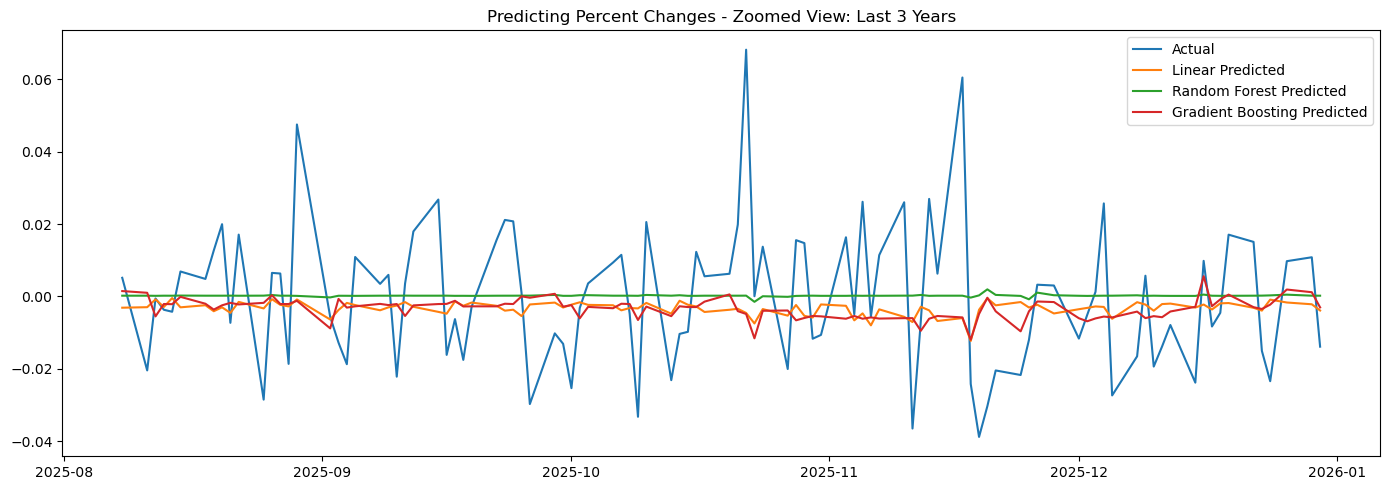

In [34]:
dates = predict_change.loc[y3_test.index, "Date"]

window = 100  # last 3 years

plt.figure(figsize=(14, 5))
plt.plot(dates[-window:], y3_test.values[-window:], label="Actual")
for name, preds in predictions.items():
    plt.plot(dates[-window:], preds[-window:], label=f"{name} Predicted")

plt.title("Predicting Percent Changes - Zoomed View: Last 3 Years")
plt.legend()
plt.tight_layout()
plt.show()

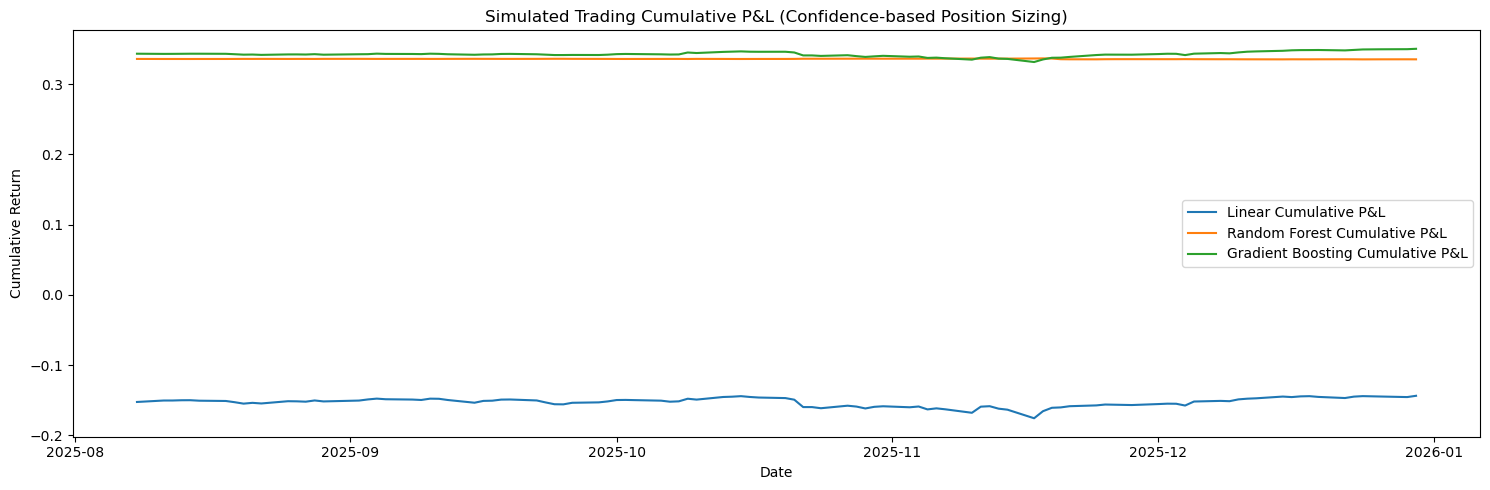

In [35]:
plt.figure(figsize=(15, 5))
for name, cum_pl in cumulative_PL.items():
    plt.plot(dates[-window:], cum_pl[-window:], label=f"{name} Cumulative P&L")

plt.title("Simulated Trading Cumulative P&L (Confidence-based Position Sizing)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
dump(trained_models["Linear"], "linear_model.joblib")

['linear_model.joblib']

In [37]:
dump(trained_models["Random Forest"], "rf_model.joblib")

['rf_model.joblib']

In [38]:
dump(trained_models["Gradient Boosting"], "gbr_model.joblib")

['gbr_model.joblib']